# Initialization

In [9]:
import pandas as pd
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import sklearn

load_dotenv()

engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASS')}@{os.getenv('DB_HOST')}:5432/{os.getenv('DB_NAME')}"
)

### Combining the recent_tables and its audio features

In [10]:
df_all = pd.read_sql("""
SELECT a.*
FROM recent_tracks_audio_features a
JOIN recent_tracks r
ON a.id = r.track_id AND a.collection_date = r.collection_date;

""", engine)

df_all.describe()
df_all.to_csv("../data/df_all.csv", index=False)

### Analyzing daily listening volume

<Axes: title={'center': 'Daily Listening Volume'}, xlabel='collection_date'>

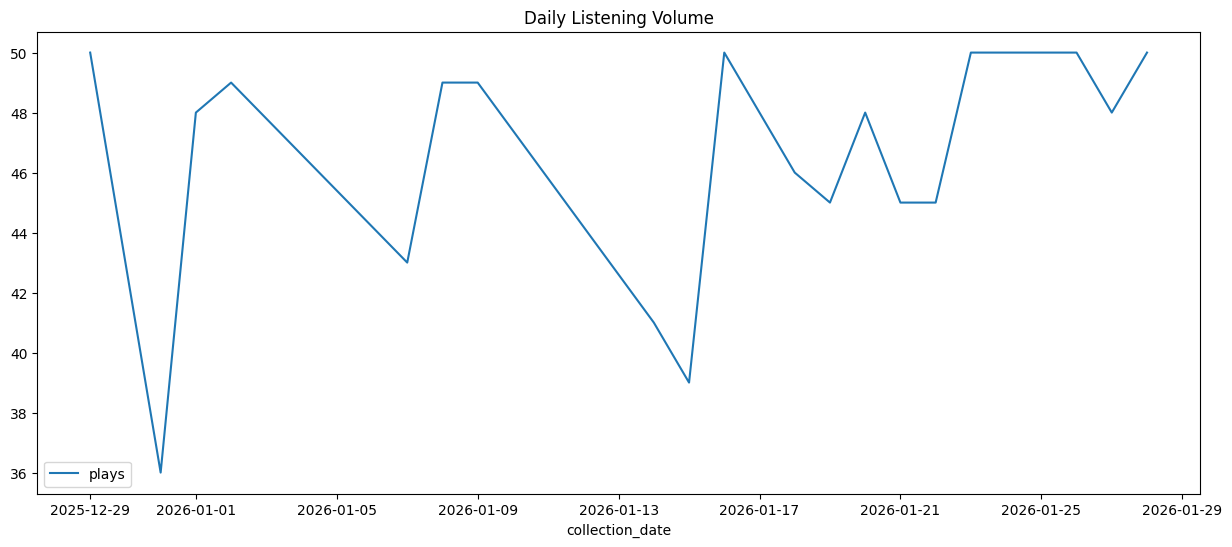

In [11]:
df = pd.read_sql("""
SELECT collection_date, COUNT(*) AS plays
FROM recent_tracks
WHERE collection_date >= '2025-12-29'
GROUP BY collection_date
ORDER BY collection_date
""", engine)

df.plot(x="collection_date", y="plays", title="Daily Listening Volume", figsize=(15, 6))

In [12]:
df.describe()

,plays
count,22.000000
mean,46.772727
std,3.951272
min,36.000000
25%,45.000000
50%,48.000000
75%,50.000000
max,50.000000


From the graph, we can see that the plays are typically around 50 with the max being 50 plays a day and a mean of 46 plays a day. The lowest amount of plays per day was 36. The max no. of tracks you can get from Spotify API is also 50 tracks.

### Analyzing number of unique plays

We want to look at the unique number of tracks played per day to see if the user is repeating listening or exploring new songs often.

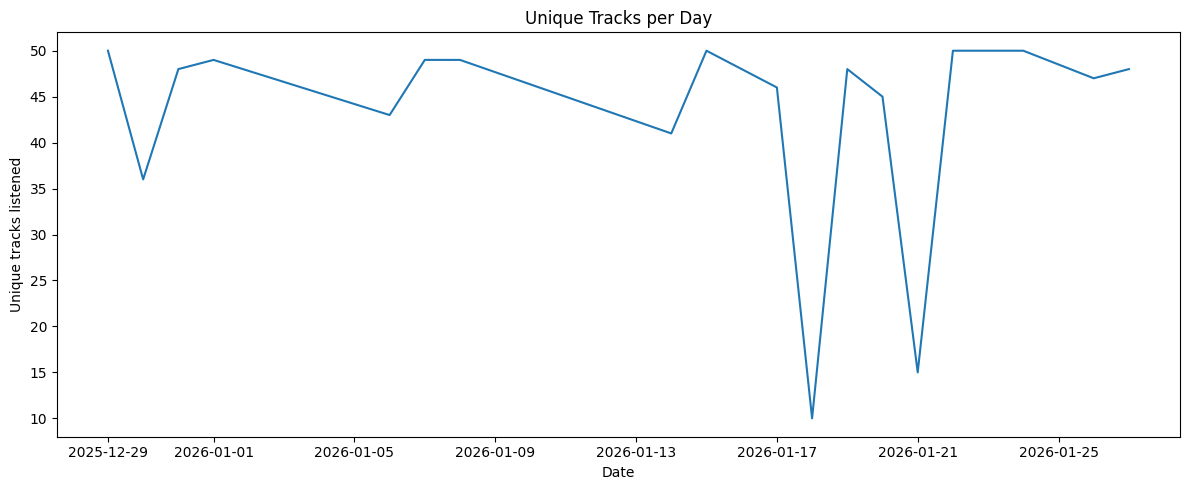

In [13]:
df = pd.read_sql("""
SELECT
    played_at::date AS day,
    COUNT(DISTINCT track_id) AS unique_tracks
FROM recent_tracks
WHERE played_at >= '2025-12-29'
GROUP BY day
ORDER BY day;
""", engine)

plt.figure(figsize=(12, 5))
plt.plot(df["day"], df["unique_tracks"])
plt.xlabel("Date")
plt.ylabel("Unique tracks listened")
plt.title("Unique Tracks per Day")
plt.tight_layout()
plt.show()

This is another plot of unique plays across the user's whole listening history and not just per day.

<Axes: title={'center': 'New (Globally Unique) Tracks per Day'}, xlabel='day'>

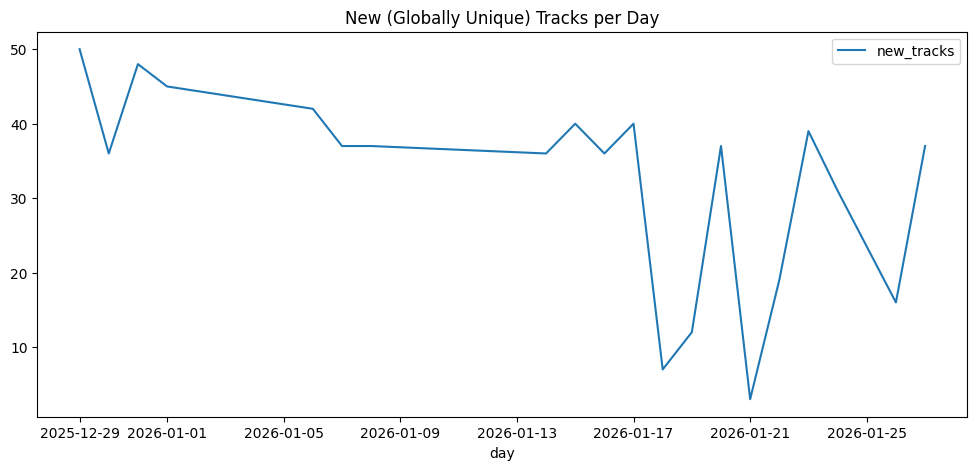

: 

: 

: 

: 

In [ ]:
df = pd.read_sql("""
    SELECT track_id, played_at::date AS day
    FROM recent_tracks
    WHERE played_at IS NOT NULL AND played_at >= '2025-12-29'
""", engine)

df["first_day"] = df.groupby("track_id")["day"].transform("min")

new_tracks_per_day = (
    df[df["day"] == df["first_day"]]
    .groupby("day")["track_id"]
    .nunique()
    .reset_index(name="new_tracks")
)


new_tracks_per_day.plot(
    x="day",
    y="new_tracks",
    figsize=(12, 5),
    title="New (Globally Unique) Tracks per Day"
)


We can see that the user explores new tracks often.

### Exploring recent top tracks and artists

<Axes: title={'center': 'Daily Listening Volume'}, xlabel='track_name'>

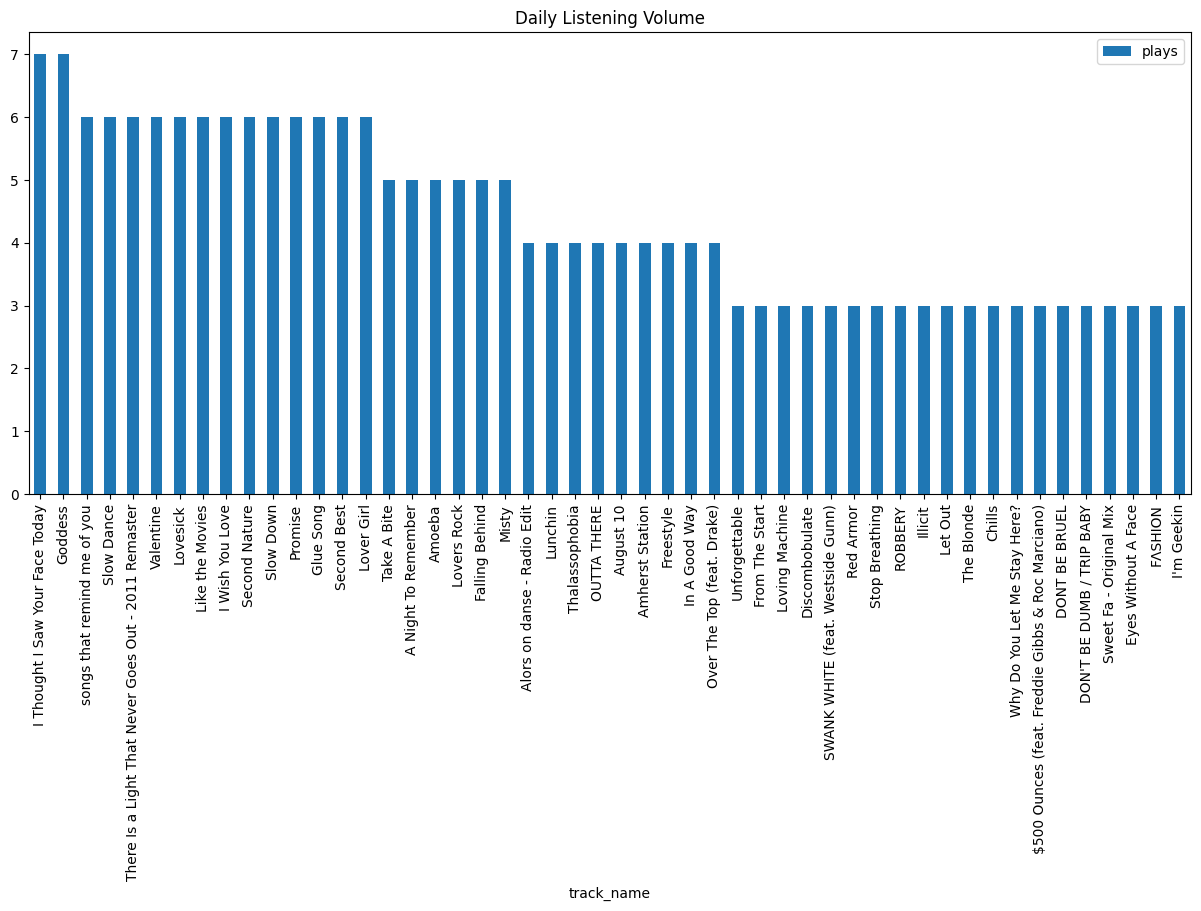

In [18]:
df = pd.read_sql("""
SELECT track_name, COUNT(*) AS plays
FROM recent_tracks
WHERE collection_date >= '2025-12-29'
GROUP BY track_name
ORDER BY plays DESC
LIMIT 50;
""", engine)

# for artists with $ in their names
# df["artist_name"] = df["artist_name"].str.replace("$", r"\$", regex=False)

df.plot(
    x="track_name",
    y="plays",
    title=r"Daily Listening Volume",
    figsize=(15, 6),
    kind="bar"
)


<Axes: title={'center': 'Daily Listening Volume'}, xlabel='artist_name'>

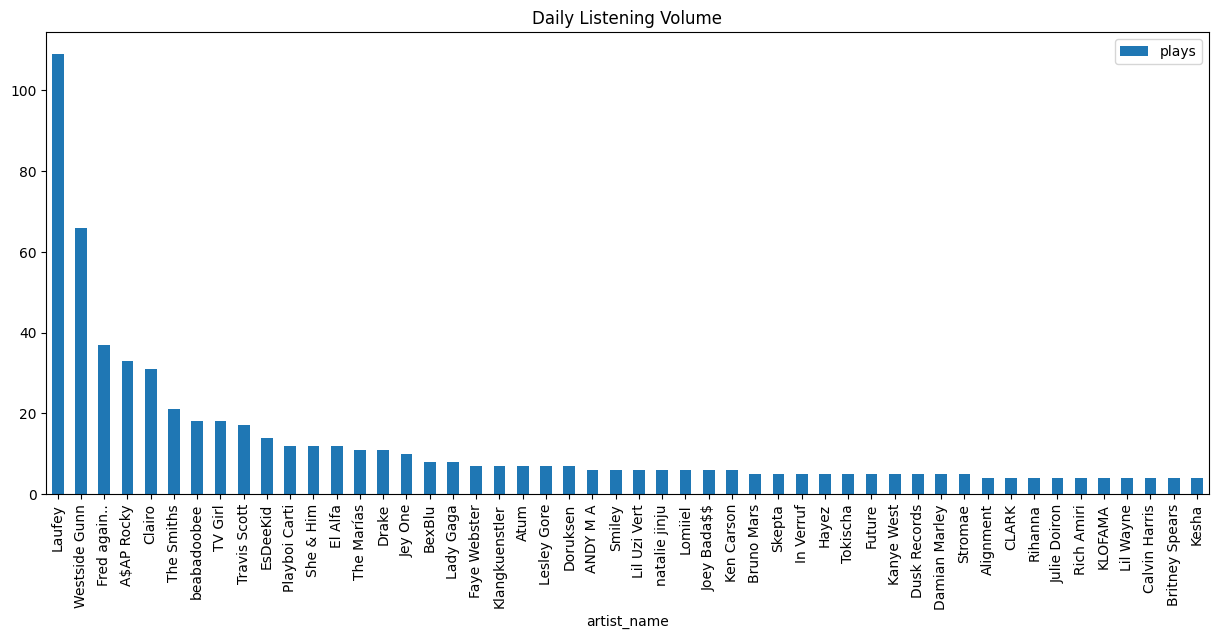

In [19]:
df = pd.read_sql("""
SELECT artist_name, COUNT(*) AS plays
FROM recent_tracks
WHERE collection_date >= '2025-12-29'
GROUP BY artist_name
ORDER BY plays DESC
LIMIT 50;
""", engine)

# for artists with $ in their names
df["artist_name"] = df["artist_name"].str.replace("$", r"\$", regex=False)

df.plot(
    x="artist_name",
    y="plays",
    title=r"Daily Listening Volume",
    figsize=(15, 6),
    kind="bar"
)


### Audio Features Distributions

(-0.5, 1.5)

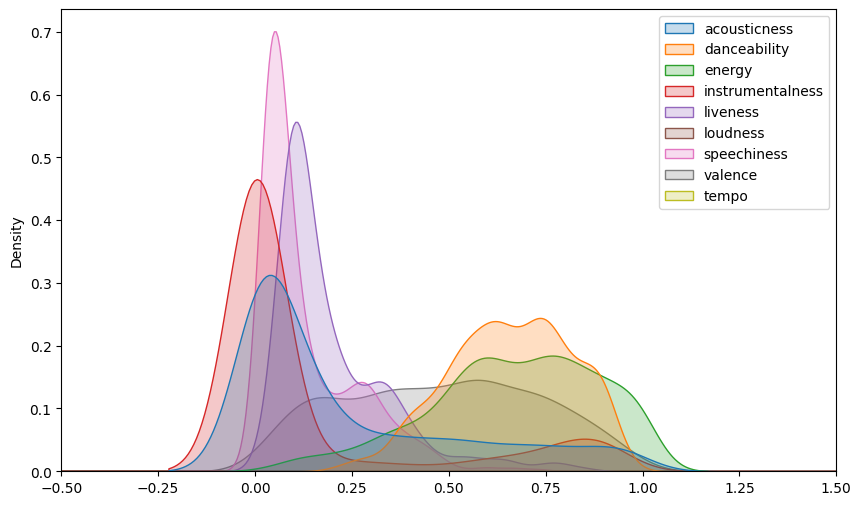

In [20]:
features = [
    "acousticness", "danceability", "energy",
    "instrumentalness", "liveness", "loudness",
    "speechiness", "valence", "tempo"
]

df = pd.read_sql("""
SELECT * FROM recent_tracks_audio_features;
""", engine)

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[features], fill=True) # for kde plot
plt.xlim(-0.5, 1.5)

array([[<Axes: title={'center': 'acousticness'}>,
        <Axes: title={'center': 'danceability'}>,
        <Axes: title={'center': 'energy'}>],
       [<Axes: title={'center': 'instrumentalness'}>,
        <Axes: title={'center': 'liveness'}>,
        <Axes: title={'center': 'loudness'}>],
       [<Axes: title={'center': 'speechiness'}>,
        <Axes: title={'center': 'valence'}>,
        <Axes: title={'center': 'tempo'}>]], dtype=object)

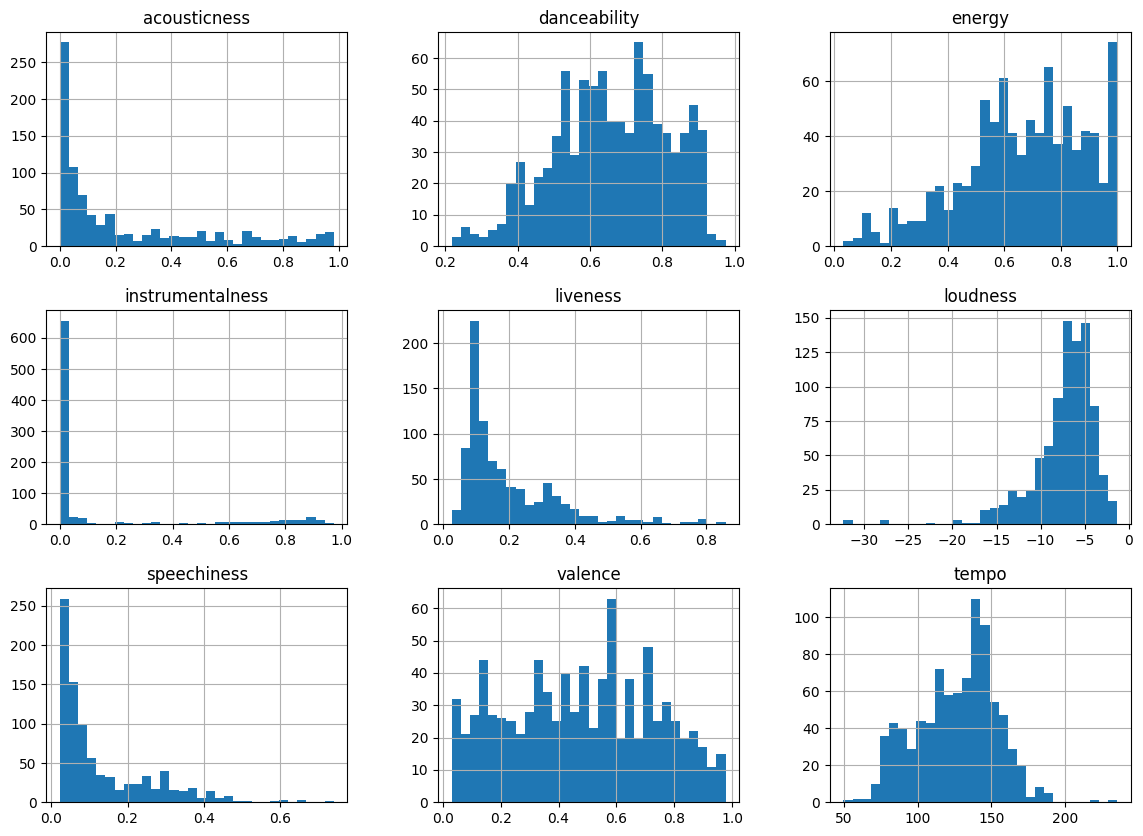

In [21]:
df = pd.read_sql("""
SELECT * FROM recent_tracks_audio_features;
""", engine)

df[features].hist(bins=30, figsize=(14,10))
# sns.kdeplot(data=df[features], fill=True) # for kde plot

In [22]:
df[features].corr().round(2)

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence,tempo
acousticness,1.00,-0.28,-0.58,-0.23,-0.12,-0.53,0.02,0.05,-0.30
danceability,-0.28,1.00,0.06,-0.16,-0.05,0.26,0.13,0.35,0.04
energy,-0.58,0.06,1.00,0.40,0.20,0.63,0.02,0.09,0.28
instrumentalness,-0.23,-0.16,0.40,1.00,-0.03,-0.06,-0.18,-0.38,0.26
liveness,-0.12,-0.05,0.20,-0.03,1.00,0.14,0.15,0.01,0.01
loudness,-0.53,0.26,0.63,-0.06,0.14,1.00,-0.07,0.20,0.16
speechiness,0.02,0.13,0.02,-0.18,0.15,-0.07,1.00,0.16,0.16
valence,0.05,0.35,0.09,-0.38,0.01,0.20,0.16,1.00,-0.09
tempo,-0.30,0.04,0.28,0.26,0.01,0.16,0.16,-0.09,1.00


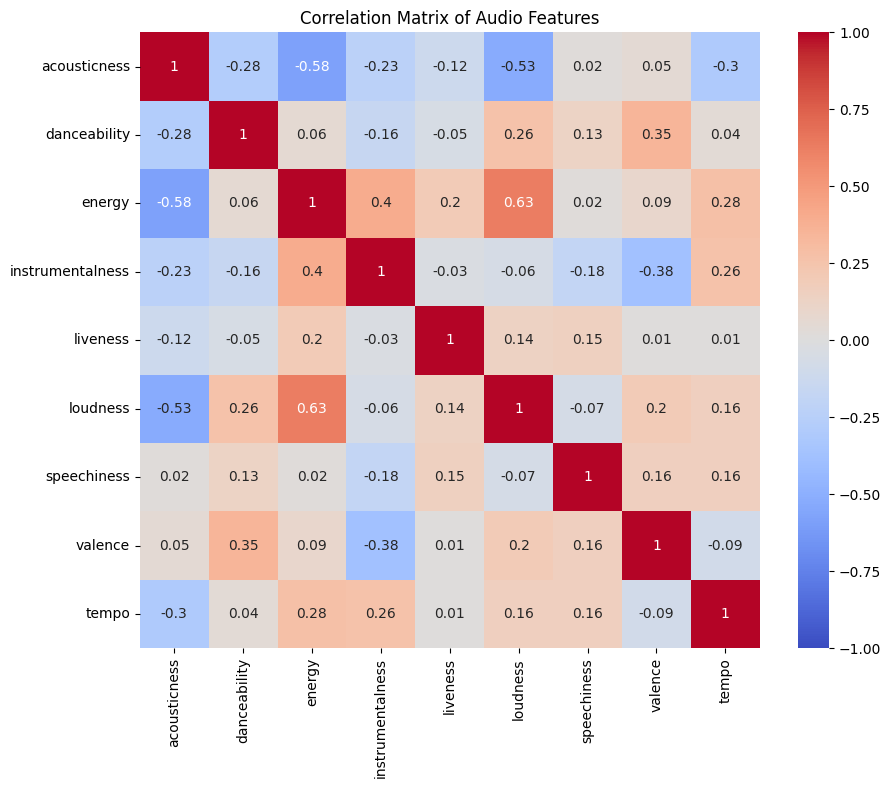

In [23]:
df_corr = df[features].corr().round(2)
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Audio Features")
plt.show()

### PCA

In [88]:
X = df[features]
# print(X)
# X = X[~pd.isnull(X).any(axis=1)]  # Remove rows with NaN values
X = X.dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_scaled)

# df["pca_1"] = X_reduced[:, 0]
# df["pca_2"] = X_reduced[:, 1]

print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[0.27905307 0.19982283]
0.4788759048934328


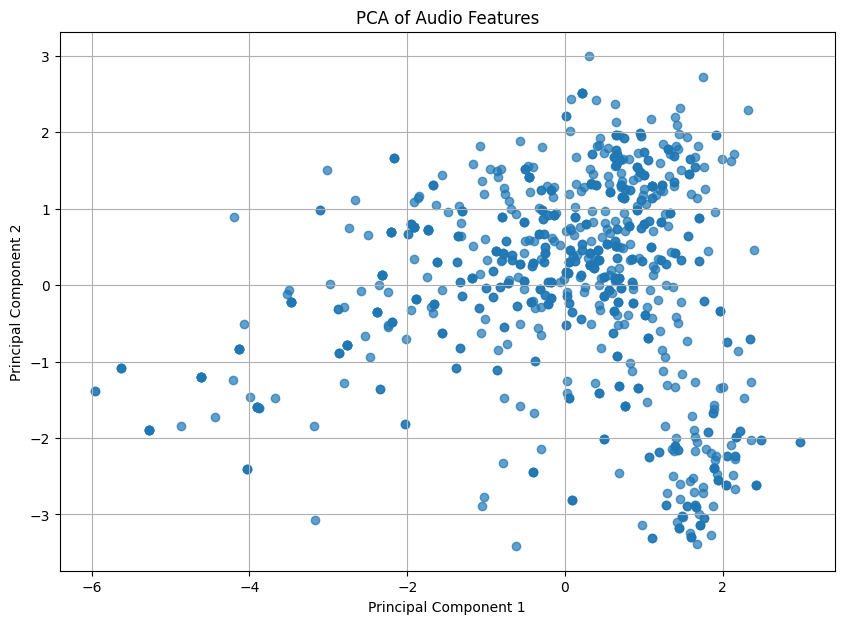

In [89]:

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], alpha =0.7)
plt.title("PCA of Audio Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid()
plt.show()

### Clustering for labels

In [90]:
model = sklearn.cluster.KMeans(n_clusters=8, random_state=42)
clusters = model.fit_predict(X_scaled)

# plt.figure(figsize=(10, 7))
# plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=clusters, cmap='viridis', alpha=0.5)
# plt.title("K-Means Clustering of Audio Features (PCA Reduced)")
# plt.xlabel("Principal Component 1")
# plt.ylabel("Principal Component 2")
# plt.grid()
# plt.show()


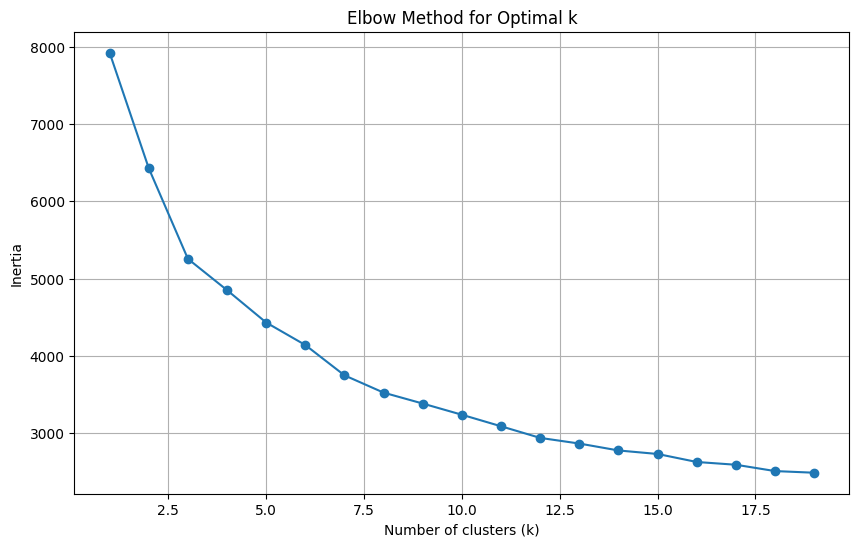

In [91]:
ks = range(1,20)
errors = []

for k in ks:
    model = sklearn.cluster.KMeans(n_clusters=k, random_state=42)
    clusters = model.fit_predict(X_scaled)
    error = model.inertia_
    errors.append(error)

plt.figure(figsize=(10, 6))
plt.plot(ks, errors, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.grid()

In [98]:
k = 7
model = sklearn.cluster.KMeans(n_clusters=k, random_state=42)
clusters = model.fit_predict(X_scaled)

# plt.figure(figsize=(10, 7))
# plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=clusters, cmap='viridis', alpha=0.5)
# plt.title("K-Means Clustering of Audio Features (PCA Reduced)")
# plt.xlabel("Principal Component 1")
# plt.ylabel("Principal Component 2")
# plt.grid()
# plt.show()


In [104]:
centroids = pd.DataFrame(
    model.cluster_centers_,
    columns=features
)

# unscale so values are human-readable
centroids_unscaled = pd.DataFrame(
    scaler.inverse_transform(centroids),
    columns=features
)

centroids_unscaled.describe()
print(centroids_unscaled)

   acousticness  danceability    energy  instrumentalness  liveness  \
0      0.124396      0.794227  0.545235          0.014635  0.146563   
1      0.138204      0.545415  0.724932          0.011585  0.192611   
2      0.133309      0.765172  0.748894          0.033208  0.153609   
3      0.032633      0.588024  0.910795          0.790606  0.182439   
4      0.729501      0.552431  0.351294          0.069473  0.132042   
5      0.166759      0.624219  0.801063          0.042279  0.564047   
6      0.303449      0.663773  0.663433          0.007852  0.247348   

    loudness  speechiness   valence       tempo  
0  -7.050159     0.163784  0.332517  124.554811  
1  -5.667822     0.071927  0.384855  136.728432  
2  -5.463424     0.087944  0.747182  118.709025  
3  -7.229079     0.085915  0.234422  144.904795  
4 -12.134931     0.086340  0.424276  105.755382  
5  -5.711234     0.163389  0.461213  113.020531  
6  -7.570031     0.368361  0.656938  147.187361  


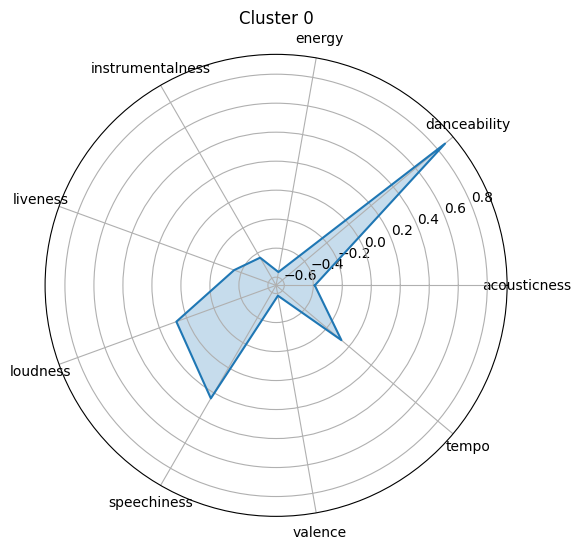

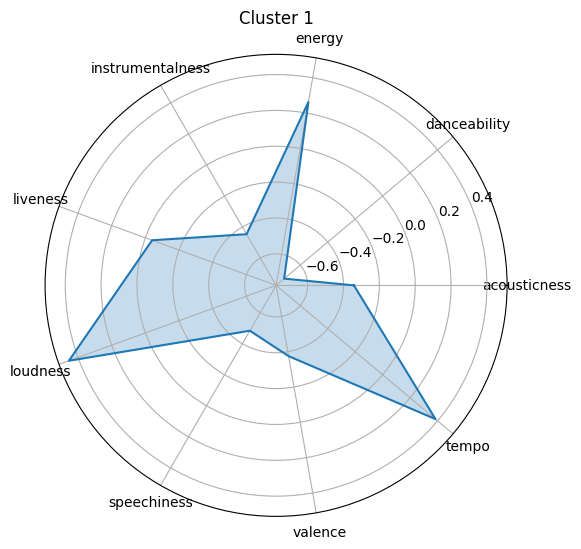

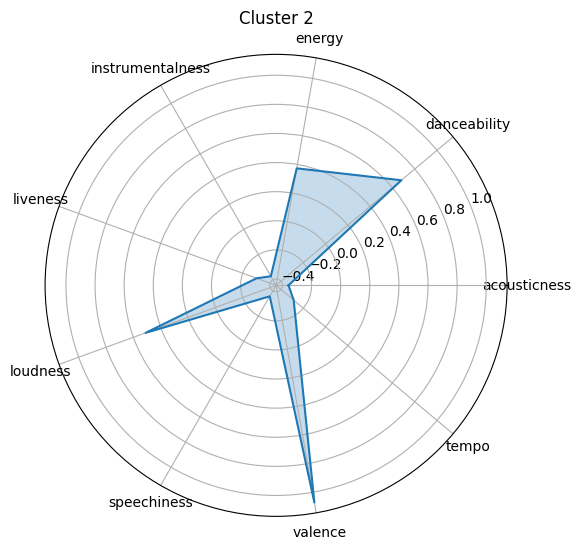

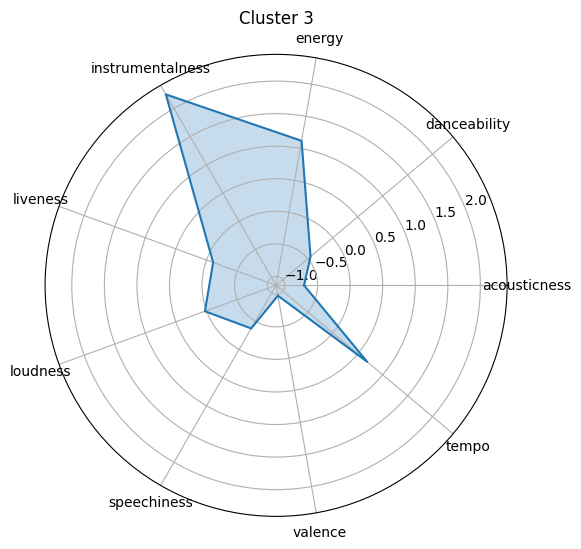

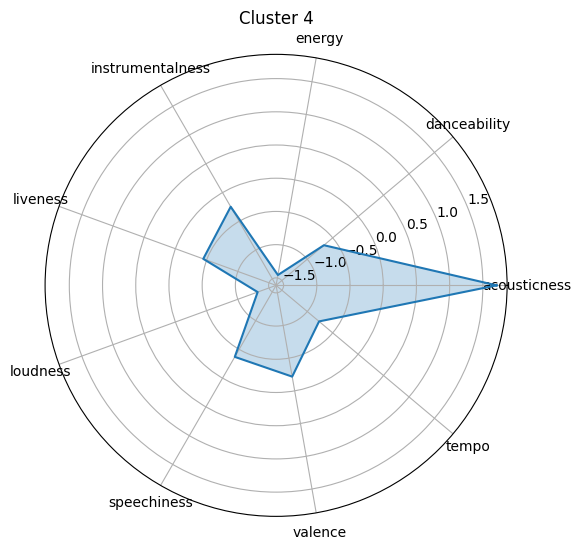

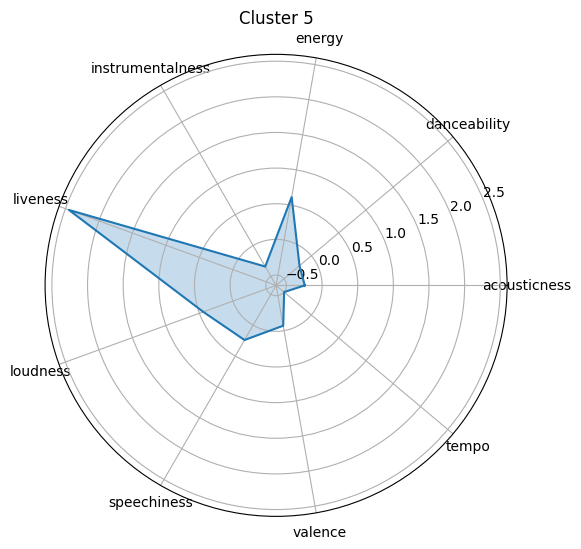

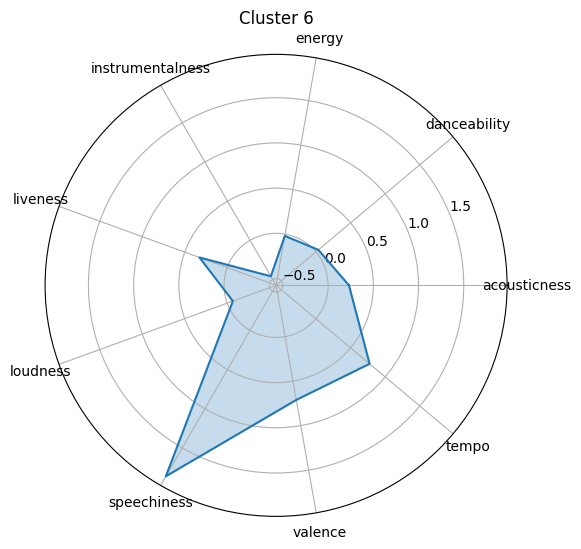

In [101]:
import numpy as np

def radar_plot(row, title):
    values = row.values.tolist()
    values += values[:1]

    angles = np.linspace(0, 2*np.pi, len(features), endpoint=False).tolist()
    angles += angles[:1]

    plt.figure(figsize=(6, 6))
    ax = plt.subplot(111, polar=True)
    ax.plot(angles, values)
    ax.fill(angles, values, alpha=0.25)
    ax.set_thetagrids(np.degrees(angles[:-1]), features)
    plt.title(title)
    plt.show()

for i in range(k):
    radar_plot(centroids.iloc[i], f"Cluster {i}")


From the radar plots, we can classify the clusters into "vibes" based on the values of the features and the description of the features (fed into ChatGPT to determine the "vibe")
- Cluster 0:
    danceability ↑ (0.79)
    energy ~ mid (0.55)
    acousticness ↓
    instrumentalness ↓
    valence ↓
    tempo ~ 125
    
    -> Rhythm-Driven Chill Pop
        Danceable, controlled energy, emotionally neutral

- Cluster 1:
    energy ↑ (0.72)
    tempo ↑ (~137 BPM)
    loudness ↑ (-5.7 dB)
    danceability ~ mid
    speechiness ↓

    -> High-Energy Vocal Tracks
        Intense, fast, vocal-driven music

- Cluster 2:
    danceability ↑
    energy ↑
    valence ↑ (0.75)
    tempo ~ mid

    -> Upbeat Dance Music
        Energetic, rhythmic, emotionally positive

- Cluster 3:
    energy ↑↑ (0.91)
    instrumentalness ↑↑ (0.79)
    tempo ↑ (~145 BPM)
    valence ↓

    -> High-Intensity Instrumentals
        Fast, instrumental, emotionally dark

- Cluster 4:
    acousticness ↑↑ (0.73)
    energy ↓
    loudness ↓↓ (-12 dB)
    tempo ↓ (~106 BPM)

    -> Acoustic & Low-Energy Tracks
        Soft, natural, relaxed listening

- Cluster 5:
    energy ↑
    liveness ↑ (0.56)
    danceability ~ mid

    -> Energetic Live-Feel Tracks
        Performance-oriented, lively recordings

- Cluster 6:
    speechiness ↑ (0.37)
    tempo ↑ (~147 BPM)
    energy ~ mid-high
    valence ↑

    -> High-Tempo Speech-Heavy Tracks
        Fast, expressive, rhythm-focused vocals


### Genre analysis